In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

from microfit import detsys
from microfit import xsec_covariances as xs
from microfit.xsec_signal_generator import XsecCovarHistGenerator

In [3]:
keep_vars = [
    "Signal_1e1p", "mc_signal_1e1p", "nu_pdg", "TrueElecIdx", "TrueLeadProtonIdx", "InFV", "HasNoMesons", "TrueNElec", "TrueNProt", 
    "TrueDeltaPT", "TrueDeltaAlphaT", "TruePN", "TrueAlpha3D",
    "TrueLeadProtonKE", "TrueLeadProtonModMom", "TrueLeadProtonE", "TrueLeadProtonMomX", "TrueLeadProtonMomY", "TrueLeadProtonMomZ",
    "TrueElecKE", "TrueElecModMom", "TrueElecE", "TrueElecMomX", "TrueElecMomY", "TrueElecMomZ",

    "Sel_1e1p", "sel_1e1p_w_cuts", "RecoElectronCandidateIdx", "RecoLeadProtonCandidateIdx", "InFV_reco",
    "RecoElecPassMomCut", "RecoLeadProtonPassMomCut", "n_reco_tracks", "n_reco_showers",
    "RecoDeltaPT", "RecoDeltaAlphaT", "RecoPN", "RecoAlpha3D", "RecoECal", "Reco_mag_q", "RecoPL",
    "RecoLeadProtonKE", "RecoLeadProtonModMom", "RecoLeadProtonMomX", "RecoLeadProtonMomY", "RecoLeadProtonMomZ",
    "RecoElecE", "RecoElecModMom", "RecoElecMomX", "RecoElecMomY", "RecoElecMomZ",

    "RecoLeadProton_trk_len", "RecoLeadProton_trk_trunk_dEdx_y", "RecoLeadProton_dEdx_y_per_trklen",
    "RecoLeadProtonCandidate_trk_pid", "RecoElectronCandidate_shr_pid", "RecoElectron_conversion_dist",

    "nproton", "npion", "npi0", "nelec", "nmuon", "isVtxInFiducial",

    "nslice", "selected", "shr_energy_tot_cali", "_opfilter_pe_beam", "_opfilter_pe_veto", "bnbdata", "extdata",
    "CosmicIPAll3D", "hits_ratio", "shrmoliereavg", "subcluster", "trkfit", "trkshrhitdist2", "tksh_distance",
    "shr_tkfit_nhits_tot", "shr_tkfit_dedx_max", "tksh_angle", "shr_trk_len", "reco_e",
    "trkpid", "trk_len", "n_showers_contained", "protonenergy_corr", "n_tracks_contained",
    "pi0_radlen1", "pi0_radlen2", "pi0_score", "nonpi0_score", "bkg_score",

    # "InFV_1muNp", "TrueMuonIdx_1muNp", "TrueLeadProtonIdx_1muNp", "TrueNProt_1muNp", "TrueFSPions_1muNp", "Signal_1mu1p", 
    # "TrueDeltaPT_1mu1p", "TrueDeltaAlphaT_1mu1p", "TruePN_1mu1p", "TrueAlpha3D_1mu1p",
    # "TrueLeadProtonE_1muNp", "TrueLeadProtonMomX_1muNp", "TrueLeadProtonMomY_1muNp", "TrueLeadProtonMomZ_1muNp",
    # "TrueMuonE_1muNp", "TrueMuonMomX_1muNp", "TrueMuonMomY_1muNp", "TrueMuonMomZ_1muNp",

    # "sel_CC1p0pi", "InFV_reco_1muNp", "MuonCandidateIdx_1muNp", "LeadProtonIdx_1muNp", "LeadProtonPassMomentumCut_1muNp", "PFPStartsInPCV_1muNp", "PassTopoScoreCut_1muNp",
    # "PassNuMuCCSelection_1muNp", "NoRecoShowers_1muNp", "MuonContained_1muNp", "PassMuonMomentumCut_1muNp", "PassMuonQualCut_1muNp",
    # "LeadProtonPassMomentumCut_1muNp", "NProtons_1muNp",
    # "RecoDeltaPT_1mu1p", "RecoDeltaAlphaT_1mu1p", "RecoPN_1mu1p", "RecoAlpha3D_1mu1p", "RecoECal_1mu1p", "RecoPL_1mu1p",
    # "RecoLeadProtonE_1muNp", "RecoLeadProtonMomentum_1muNp", "RecoLeadProtonMomX_1muNp", "RecoLeadProtonMomY_1muNp", "RecoLeadProtonMomZ_1muNp", 
    # "RecoMuonE_1muNp", "RecoMuonMomentum_1muNp", "RecoMuonMomX_1muNp", "RecoMuonMomY_1muNp", "RecoMuonMomZ_1muNp",
]

In [4]:
RUN = ["3"]
blinded = True
data="bnb"

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data=data,
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=True,
    load_lee=False,
    #load_numu_tki=True,
    load_nue_tki=True,
    keep_columns=keep_vars,
    blinded=blinded,
    load_crt_vars=False,
    enable_cache=True,
)

Loading run 3
Updating keep_columns with truth-filtering variables: {'nu_pdg', 'ccnc'}
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/bnb_beam_off_peleeTuple_uboone_v08_00_00_70_run3.root
Loading data from: /exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/bnb_beam_off_peleeTuple_uboone_v08_00_00_70_run3.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only


/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/pandas/core/generic.py:2505: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->boolean,key->block6_values] [items->Index(['Signal_1e1p', 'Sel_1e1p'], dtype='object')]

  encoding=encoding,


/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/overlay_peleeTuple_uboone_v08_00_00_70_run3_nu.root
Loading data from: /exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/overlay_peleeTuple_uboone_v08_00_00_70_run3_nu.root


../../data_loading.py:876: RuntimeWarning: invalid value encountered in true_divide
  df["proton_pz"] = np.where((mc_E_prot > 0), mc_pz_prot / mc_p_prot, np.nan)


Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only


/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/pandas/core/generic.py:2505: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['weightsGenie', 'weightsFlux', 'weightsReint', 'Signal_1e1p',
       'Sel_1e1p'],
      dtype='object')]

  encoding=encoding,


/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/overlay_peleeTuple_uboone_v08_00_00_70_run3_nue.root
Loading data from: /exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/overlay_peleeTuple_uboone_v08_00_00_70_run3_nue.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/overlay_peleeTuple_uboone_v08_00_00_70_run3_dirt.root
Loading data from: /exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/overlay_peleeTuple_uboone_v08_00_00_70_run3_dirt.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only


In [5]:
run_combo = "Run"
for run in RUN:
    run_combo += run

In [14]:
all_mc = pd.concat([df for k, df in rundata.items() if k!='data'])
from microfit import selections as sel
presel_query = f"{sel.preselection_categories[preselection]['query']}"
presel_title = f"{sel.preselection_categories[preselection]['title']}"
presel_mc = all_mc.query(presel_query, engine='python')
is_sig = presel_mc['category_1e1p'] == 12
all_sig = presel_mc.loc[is_sig]
all_bkg = presel_mc.loc[~is_sig]

selection = "OnePBDT"
preselection = "OneP_new"
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
title = f"{sel.preselection_categories[preselection]['title']} and {sel.selection_categories[selection]['title']}"
sel_mc = all_mc.query(query, engine='python')

is_sig = sel_mc['category_1e1p'] == 12
sel_sig = sel_mc.loc[is_sig]
sel_bkg = sel_mc.loc[~is_sig]

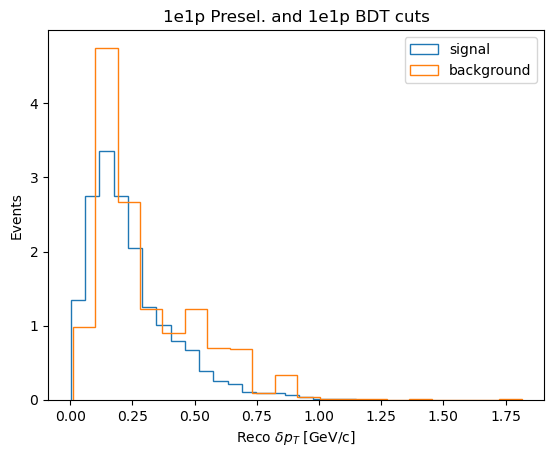

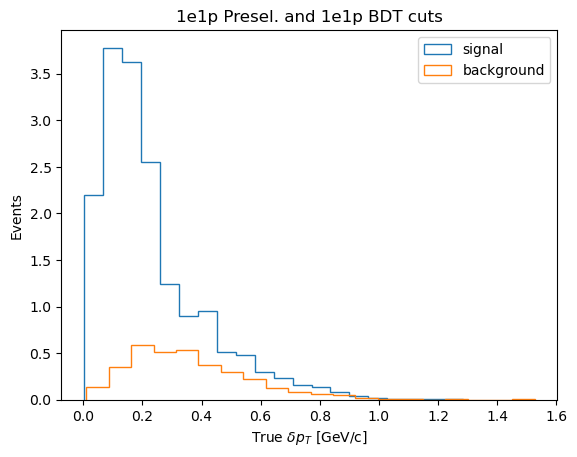

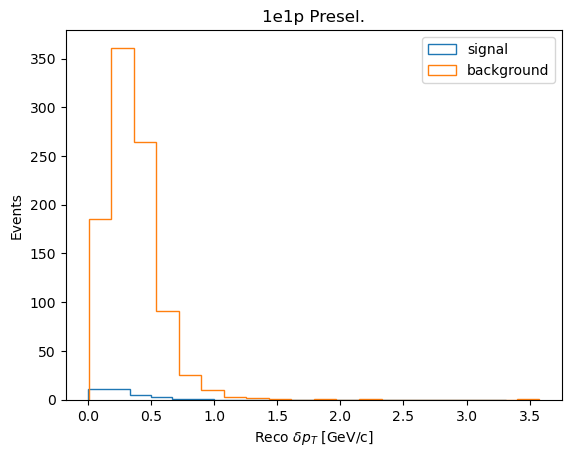

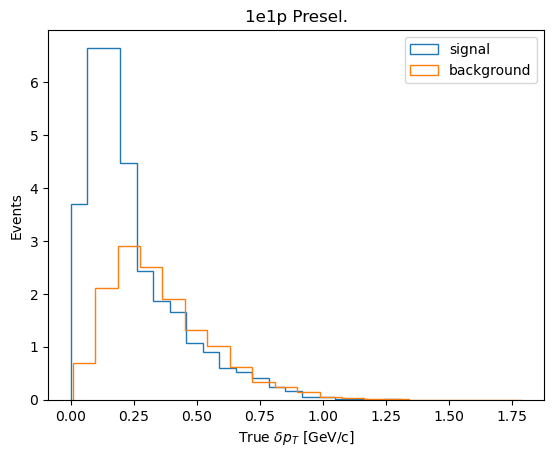

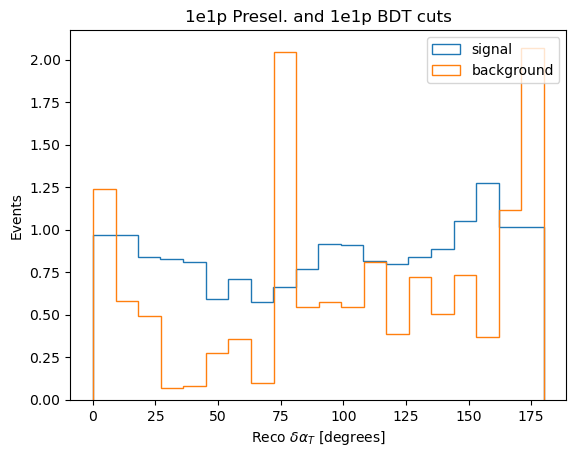

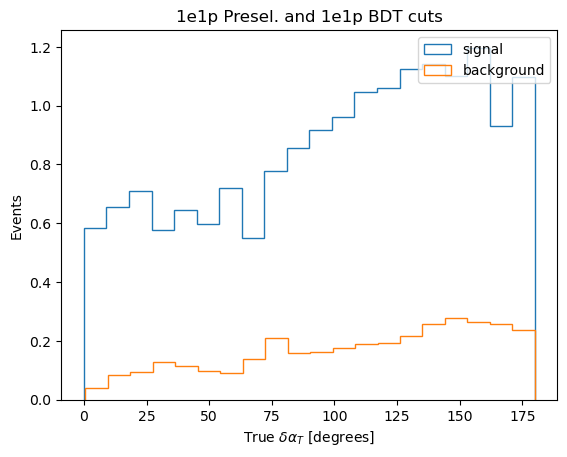

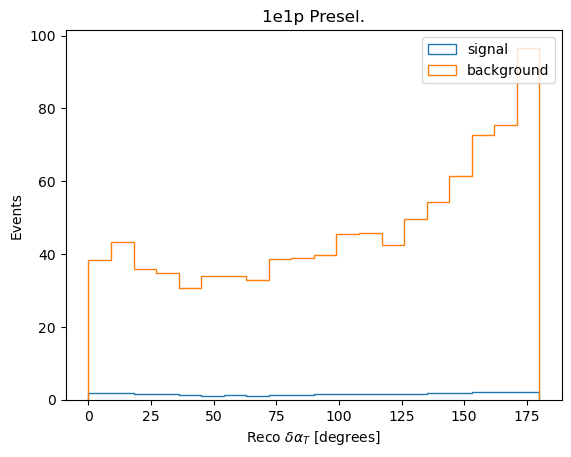

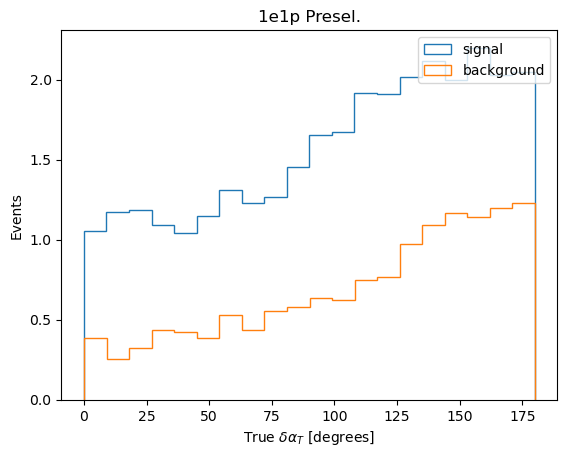

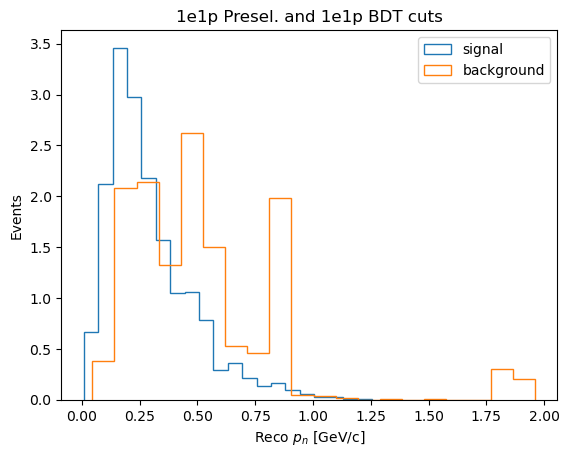

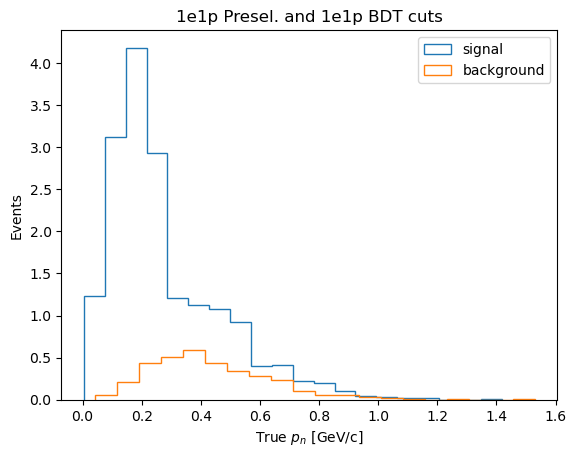

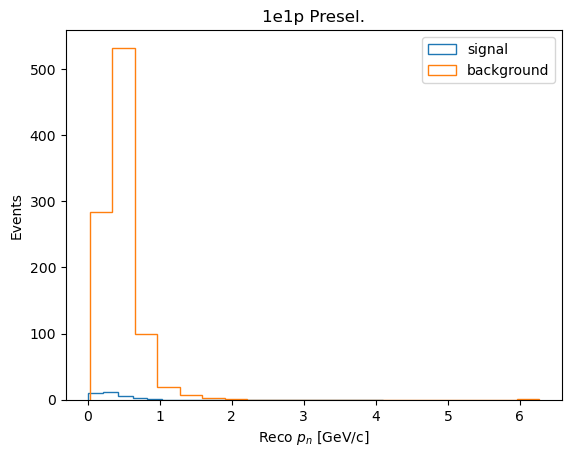

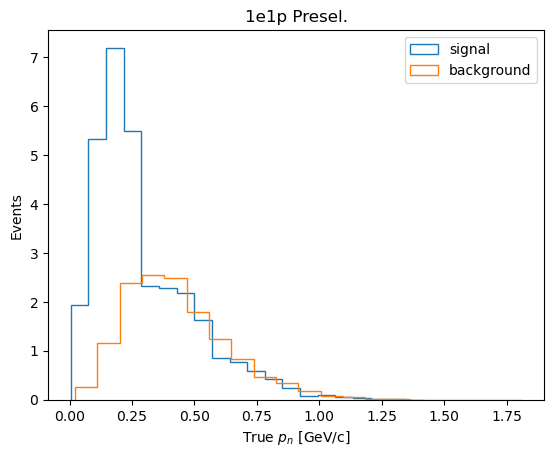

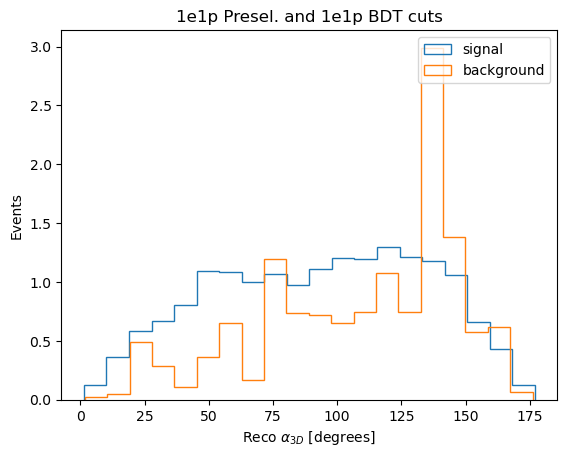

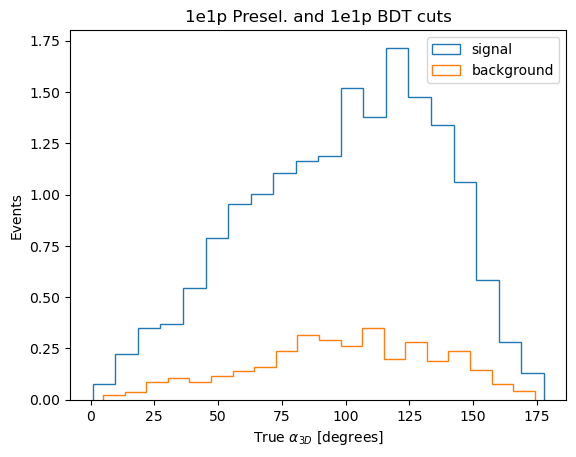

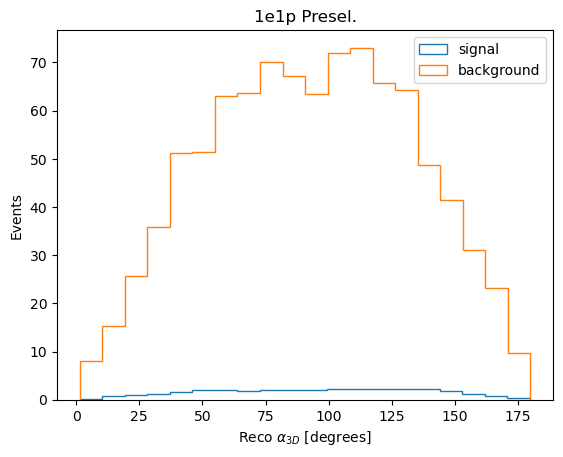

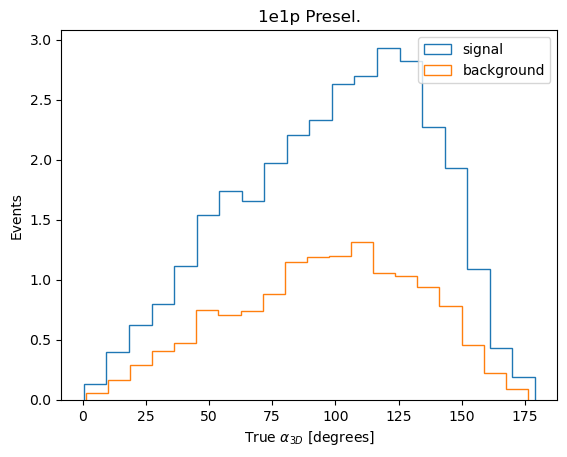

<Figure size 640x480 with 0 Axes>

In [15]:
variables = {
# #    '': {'reco': , 'truth': , 'nbins': , 'bounds': },
    # 'Proton Kinetic Energy [GeV]': {'reco': 'RecoLeadProtonKE', 'truth': 'TrueLeadProtonKE', 'nbins': 10, 'bounds': (0, 1), 'range': [[0,1.3],[0,1.3]]},
    # 'Proton Momentum [GeV/c]': {'reco': 'RecoLeadProtonModMom', 'truth': 'TrueLeadProtonModMom', 'nbins': 20, 'bounds': (0, 1.5), 'range': [[0.1,2],[0.1,2]]},
    # 'Proton X Momentum [GeV/c]': {'reco': 'RecoLeadProtonMomX', 'truth': 'TrueLeadProtonMomX', 'nbins': 20, 'bounds': (-1, 1), 'range': [[-1,1.25],[-1,1.25]]},
    # 'Proton Y Momentum [GeV/c]': {'reco': 'RecoLeadProtonMomY', 'truth': 'TrueLeadProtonMomY', 'nbins': 20, 'bounds': (-1.5, 1.5), 'range': [[-1,1.5],[-1,1.5]]},
    # 'Proton Z Momentum [GeV/c]': {'reco': 'RecoLeadProtonMomZ', 'truth': 'TrueLeadProtonMomZ', 'nbins': 20, 'bounds': (-1, 1.5),'range': [[-1,2],[-1,2]]},
    # 'Electron Energy [GeV]': {'reco': 'RecoElecE', 'truth': 'TrueElecE', 'nbins': 16, 'bounds': (0, 4), 'range': [[0,4.6],[0,4.6]]},
    # 'Electron Momentum [GeV/c]': {'reco': 'RecoElecModMom', 'truth': 'TrueElecModMom', 'nbins': 20, 'bounds': (0, 5), 'range': [[0,4.6],[0,4.6]]},
    # 'Electron X Momentum [GeV/c]': {'reco': 'RecoElecMomX', 'truth': 'TrueElecMomX', 'nbins': 12, 'bounds': (-1.5, 1.5), 'range': [[-1,1],[-1,1]]},
    # 'Electron Y Momentum [GeV/c]': {'reco': 'RecoElecMomY', 'truth': 'TrueElecMomY', 'nbins': 12, 'bounds': (-1.5, 1.5), 'range': [[-1,1],[-1,1]]},
    # 'Electron Z Momentum [GeV/c]': {'reco': 'RecoElecMomZ', 'truth': 'TrueElecMomZ', 'nbins': 12, 'bounds': (-1, 5), 'range': [[0,4.6],[0,4.6]]},
    '$\\delta p_T$ [GeV/c]': {'reco': 'RecoDeltaPT', 'truth': 'TrueDeltaPT', 'nbins': 20, 'bounds': (0, 2), 'range': [[0,1.7],[0,1.7]], 'bin_edges': [[0,0.3,1.7],[0,0.3,1.7]], 'bin_edges_1d': [0,0.3,1.7]},
    '$\\delta \\alpha_T$ [degrees]': {'reco': 'RecoDeltaAlphaT', 'truth': 'TrueDeltaAlphaT', 'nbins': 20, 'bounds': (0, 180), 'range': [[0,180],[0,180]], 'bin_edges': [[0,80,180],[0,80,180]], 'bin_edges_1d': [0,80,180]},
    '$p_n$ [GeV/c]': {'reco': 'RecoPN', 'truth': 'TruePN', 'nbins': 10, 'bounds': (0, 2), 'range': [[0,1.7],[0,1.7]], 'bin_edges': [[0,0.3,1.7],[0,0.3,1.7]], 'bin_edges_1d': [0,0.3,1.7]},
    '$\\alpha_{3D}$ [degrees]': {'reco': 'RecoAlpha3D', 'truth': 'TrueAlpha3D', 'nbins': 10, 'bounds': (0, 180), 'range': [[0,180],[0,180]], 'bin_edges': [[0,90,180],[0,90,180]], 'bin_edges_1d': [0,90,180]},
}

for k, var in variables.items():

    truth = variables[k]['truth']
    reco = variables[k]['reco']
    bounds = variables[k]['range']
    bin_edges = variables[k]['bin_edges']
    bin_edges_1d = variables[k]['bin_edges_1d']

    # Selected events

    plt.hist(sel_sig[reco], 20, weights=sel_sig["weights"], histtype='step', label='signal')
    plt.hist(sel_bkg[reco], 20, weights=sel_bkg["weights"], histtype='step', label='background')
    plt.legend()
    #plt.yscale('log')
    plt.xlabel(f'Reco {k}')
    plt.ylabel(f'Events')
    plt.title(title)
    # plt.savefig(f'plots/reco_study/full_range_{preselection}_{selection}_{data}_{run_combo}_{reco}.pdf', bbox_inches='tight')
    # plt.savefig(f'plots/reco_study/full_range_{preselection}_{selection}_{data}_{run_combo}_{reco}.png', bbox_inches='tight')
    plt.show()
    plt.clf()

    plt.hist(sel_sig[truth], 20, weights=sel_sig["weights"], histtype='step', label='signal')
    plt.hist(sel_bkg[truth], 20, weights=sel_bkg["weights"], histtype='step', label='background')
    plt.legend()
    #plt.yscale('log')
    plt.xlabel(f'True {k}')
    plt.ylabel(f'Events')
    plt.title(title)
    # plt.savefig(f'plots/reco_study/full_range_{preselection}_{selection}_{data}_{run_combo}_{truth}.pdf', bbox_inches='tight')
    # plt.savefig(f'plots/reco_study/full_range_{preselection}_{selection}_{data}_{run_combo}_{truth}.png', bbox_inches='tight')
    plt.show()
    plt.clf()

    # No selection

    plt.hist(all_sig[reco], 20, weights=all_sig["weights"], histtype='step', label='signal')
    plt.hist(all_bkg[reco], 20, weights=all_bkg["weights"], histtype='step', label='background')
    plt.legend()
    #plt.yscale('log')
    plt.xlabel(f'Reco {k}')
    plt.ylabel(f'Events')
    plt.title(presel_title)
    # plt.savefig(f'plots/reco_study/full_range_NoSel_{data}_{run_combo}_{reco}.pdf', bbox_inches='tight')
    # plt.savefig(f'plots/reco_study/full_range_NoSel_{data}_{run_combo}_{reco}.png', bbox_inches='tight')
    plt.show()
    plt.clf()

    plt.hist(all_sig[truth], 20, weights=all_sig["weights"], histtype='step', label='signal')
    plt.hist(all_bkg[truth], 20, weights=all_bkg["weights"], histtype='step', label='background')
    plt.legend()
    #plt.yscale('log')
    plt.xlabel(f'True {k}')
    plt.ylabel(f'Events')
    plt.title(presel_title)
    # plt.savefig(f'plots/reco_study/full_range_NoSel_{data}_{run_combo}_{truth}.pdf', bbox_inches='tight')
    # plt.savefig(f'plots/reco_study/full_range_NoSel_{data}_{run_combo}_{truth}.png', bbox_inches='tight')
    plt.show()
    plt.clf()